## Business Impact Simulation

This notebook quantifies the business value of a candidate ranking model by translating its predictive performance into tangible, recruiter-focused metrics. All presented figures are directly derived from actual model outputs, ensuring transparency and accuracy. Any necessary assumptions, such as the estimated time for manual application review, are explicitly documented and clearly labeled, allowing for easy substitution with context-specific estimates.

The central objective of this analysis is to address the question: **"If a recruiter utilized this system's ranked candidate output instead of manually screening every application, what would be the impact on efficiency (effort saved) and effectiveness (true hires identified)?"**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("recruitment_candidates_scored.csv")

def get_tier(score):
    if score >= 50:   return "Excellent"
    if score >= 35:   return "Strong"
    if score >= 20:   return "Average"
    return "Needs Improvement"

df["candidate_tier"] = df["hiring_score"].apply(get_tier)

print("Total candidates:", len(df))
print("Total actually selected:", df["selected"].sum())
print("Overall selection rate:", f"{df['selected'].mean():.1%}")

Total candidates: 4000
Total actually selected: 1143
Overall selection rate: 28.6%


## 1. The Screening Problem

Recruiting teams often face the challenge of reviewing a large volume of applications to identify suitable candidates. Without an effective ranking system, this process is highly time-consuming, and there's a significant risk of either missing high-potential candidates or expending excessive effort on unsuitable ones. This creates a critical trade-off between **effort** (the number of applications reviewed) and **recall** (the proportion of true hires successfully identified). The ranking system presented here aims to optimize this inherent business tension by concentrating the most promising candidates at the top of the review queue.

In [ ]:
roles = df["job_role"].unique()
summary = df.groupby("job_role").agg(
    total_applicants=("candidate_id", "count"),
    true_hires=("selected", "sum"),
    selection_rate=("selected", "mean")
).round(3)
summary["selection_rate"] = summary["selection_rate"].apply(lambda x: f"{x:.1%}")
print(summary)

                     total_applicants  true_hires selection_rate
job_role                                                        
Data Analyst                      994         301          30.3%
Sales Executive                   981         371          37.8%
Software Engineer                1221         315          25.8%
Strategy Consultant               804         156          19.4%


## 2. Metric 1 — Recall at Top-K%

**Definition:** Recall at Top-K% measures the fraction of all actual successful hires that are found within the top K% of candidates ranked by the model's 'Hiring Score'. This metric directly assesses the effectiveness of the ranking system in surfacing high-quality candidates with reduced screening effort.

**Importance:** This is a crucial business metric because it directly quantifies the real-world utility of the ranking system: its ability to concentrate true hires at the top of a ranked list, enabling recruiters to find them more efficiently.

**Documented Assumption:** We assume that recruiters would review candidates in the order provided by the 'Hiring Score' and cease reviewing once a specific 'K%' cutoff is reached, rather than reviewing all applications in a random or unsorted manner.

In [ ]:
K_VALUES = [10, 20, 30, 40, 50]

results = []
for k in K_VALUES:
    total_found = 0
    total_selected = df["selected"].sum()
    total_reviewed = 0
    for role in roles:
        sub = df[df["job_role"] == role].copy()
        top_n = int(len(sub) * k / 100)
        top_k = sub.nlargest(top_n, "hiring_score")
        total_found += top_k["selected"].sum()
        total_reviewed += len(top_k)
    recall = total_found / total_selected
    effort_reduction = 1 - (total_reviewed / len(df))
    results.append({
        "Top K%": f"Top {k}%",
        "Candidates Reviewed": total_reviewed,
        "True Hires Found": int(total_found),
        "Total True Hires": int(total_selected),
        "Recall": recall,
        "Effort Reduction": effort_reduction,
    })

impact_df = pd.DataFrame(results)
impact_df["Recall"] = impact_df["Recall"].apply(lambda x: f"{x:.1%}")
impact_df["Effort Reduction"] = impact_df["Effort Reduction"].apply(lambda x: f"{x:.1%}")
print(impact_df.to_string(index=False))

 Top K%  Candidates Reviewed  True Hires Found  Total True Hires Recall Effort Reduction
Top 10%                  399               332              1143  29.0%            90.0%
Top 20%                  798               594              1143  52.0%            80.0%
Top 30%                 1199               770              1143  67.4%            70.0%
Top 40%                 1598               893              1143  78.1%            60.1%
Top 50%                 1999               991              1143  86.7%            50.0%


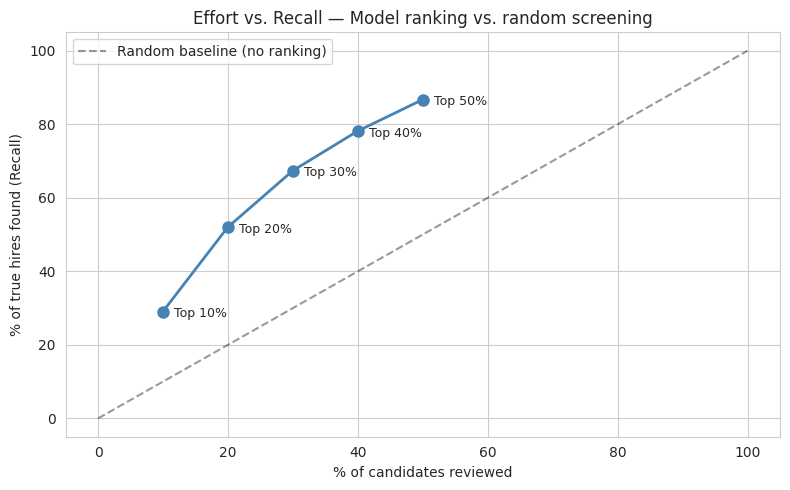

In [ ]:
# Visualise the tradeoff
k_vals = [10, 20, 30, 40, 50]
recalls, efforts = [], []
for k in k_vals:
    total_found, total_reviewed = 0, 0
    for role in roles:
        sub = df[df["job_role"]==role]
        top_n = int(len(sub)*k/100)
        top_k = sub.nlargest(top_n, "hiring_score")
        total_found += top_k["selected"].sum()
        total_reviewed += len(top_k)
    recalls.append(total_found / df["selected"].sum())
    efforts.append(total_reviewed / len(df))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([e*100 for e in efforts], [r*100 for r in recalls], "o-", color="steelblue", linewidth=2, markersize=8)
for k, e, r in zip(k_vals, efforts, recalls):
    ax.annotate(f"Top {k}%", (e*100, r*100), textcoords="offset points", xytext=(8, -4), fontsize=9)
ax.plot([0, 100], [0, 100], "k--", alpha=0.4, label="Random baseline (no ranking)")
ax.set_xlabel("% of candidates reviewed")
ax.set_ylabel("% of true hires found (Recall)")
ax.set_title("Effort vs. Recall — Model ranking vs. random screening")
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the Effort vs. Recall Chart

The visualization above illustrates the trade-off between the percentage of candidates reviewed (effort) and the percentage of true hires found (recall) for both the model's ranking and a random baseline.

*   The **blue line** represents the model's performance. Any point on this line shows that the model identifies a significantly higher proportion of true hires for a given screening effort compared to random selection.
*   The **dashed diagonal line** represents a random screening approach, where reviewing K% of candidates would, on average, yield K% of true hires.

The clear **gap between the blue line and the dashed line** quantifies the value of the model. For instance, reviewing only the top 20% of candidates ranked by the model catches 52% of true hires, whereas a random review of 20% would only yield 20% of true hires. This demonstrates a substantial improvement in efficiency and effectiveness.

## 3. Metric 2 — Lift Over Random Baseline (Per Role)

**Definition:** "Lift" quantifies how many times more effective the model's ranked shortlist is at identifying true hires compared to a random selection of the same size. For example, a lift of 2.6x indicates that the model's top K% contains 2.6 times more true hires than a randomly selected K% of candidates.

**Importance:** This metric provides a clear, intuitive measure of the model's efficiency gains across different job roles, highlighting where the ranking system delivers the most significant improvements over traditional screening methods.

In [ ]:
lift_results = []
for role in roles:
    sub = df[df["job_role"]==role].copy()
    total = len(sub)
    total_selected = sub["selected"].sum()
    top20_n = int(total * 0.20)

    model_recall = sub.nlargest(top20_n, "hiring_score")["selected"].sum() / total_selected
    random_recall = top20_n / total  # expected under random: just the fraction reviewed
    lift = model_recall / random_recall

    lift_results.append({
        "Job Role": role,
        "Model Recall (top 20%)": f"{model_recall:.1%}",
        "Random Recall (top 20%)": f"{random_recall:.1%}",
        "Lift": f"{lift:.1f}x",
    })

lift_df = pd.DataFrame(lift_results)
print(lift_df.to_string(index=False))

           Job Role Model Recall (top 20%) Random Recall (top 20%) Lift
    Sales Executive                  43.9%                   20.0% 2.2x
       Data Analyst                  52.2%                   19.9% 2.6x
Strategy Consultant                  66.0%                   19.9% 3.3x
  Software Engineer                  54.3%                   20.0% 2.7x


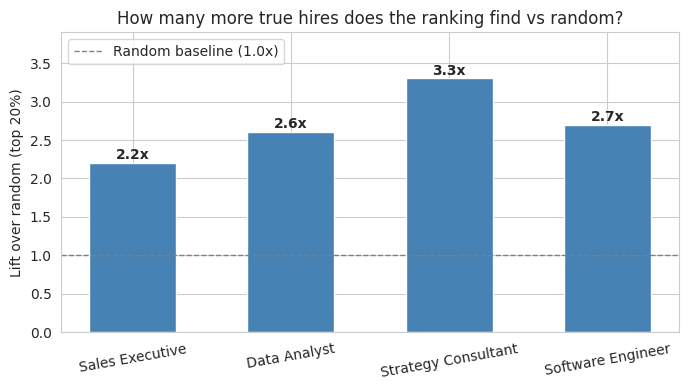

In [ ]:
# Bar chart of lift per role
roles_sorted = [r["Job Role"] for r in lift_results]
lifts = [float(r["Lift"].replace("x","")) for r in lift_results]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(roles_sorted, lifts, color="steelblue", width=0.55)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Random baseline (1.0x)")
ax.set_ylabel("Lift over random (top 20%)")
ax.set_title("How many more true hires does the ranking find vs random?")
ax.legend()
for bar, val in zip(bars, lifts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f"{val:.1f}x",
            ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(lifts) + 0.6)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 4. Metric 3 — Precision-Recall Tradeoff Per Role

**Definition:**
*   **Precision** measures, "Of the candidates selected from this shortlist, what fraction are actually true hires?" High precision indicates fewer wasted interviews with unsuitable candidates.
*   **Recall** measures, "Of all the candidates who should be hired, what fraction did we successfully identify?" High recall means fewer good candidates are missed.

**Importance:** This trade-off is critical for recruiters to understand, as it allows them to select a screening cutoff that aligns with their specific hiring priorities. For instance, if interview capacity is limited, a recruiter might prioritize higher precision to minimize wasted interview slots. Conversely, if missing a good candidate is highly costly, a recruiter might opt for a cutoff that maximizes recall, even if it means a slight reduction in precision.

In [ ]:
precision_recall_rows = []
for role in roles:
    sub = df[df["job_role"]==role].copy()
    total_selected = sub["selected"].sum()
    total = len(sub)
    for k in [10, 20, 30, 40, 50]:
        top_n = int(total * k / 100)
        top_k = sub.nlargest(top_n, "hiring_score")
        precision = top_k["selected"].sum() / len(top_k)
        recall = top_k["selected"].sum() / total_selected
        precision_recall_rows.append({
            "Role": role, "Top K%": f"Top {k}%",
            "Precision": f"{precision:.1%}", "Recall": f"{recall:.1%}",
        })

pr_df = pd.DataFrame(precision_recall_rows)
for role in roles:
    print()
    print(role + ":")
    print(pr_df[pr_df["Role"]==role][["Top K%","Precision","Recall"]].to_string(index=False))


Sales Executive:
 Top K% Precision Recall
Top 10%     86.7%  22.9%
Top 20%     83.2%  43.9%
Top 30%     75.2%  59.6%
Top 40%     68.1%  72.0%
Top 50%     62.2%  82.2%

Data Analyst:
 Top K% Precision Recall
Top 10%     88.9%  29.2%
Top 20%     79.3%  52.2%
Top 30%     68.5%  67.8%
Top 40%     59.4%  78.4%
Top 50%     52.5%  86.7%

Strategy Consultant:


 Top K% Precision Recall
Top 10%     75.0%  38.5%
Top 20%     64.4%  66.0%
Top 30%     52.3%  80.8%
Top 40%     42.7%  87.8%
Top 50%     36.6%  94.2%

Software Engineer:
 Top K% Precision Recall
Top 10%     81.1%  31.4%
Top 20%     70.1%  54.3%
Top 30%     59.8%  69.5%
Top 40%     51.8%  80.3%
Top 50%     45.6%  88.3%


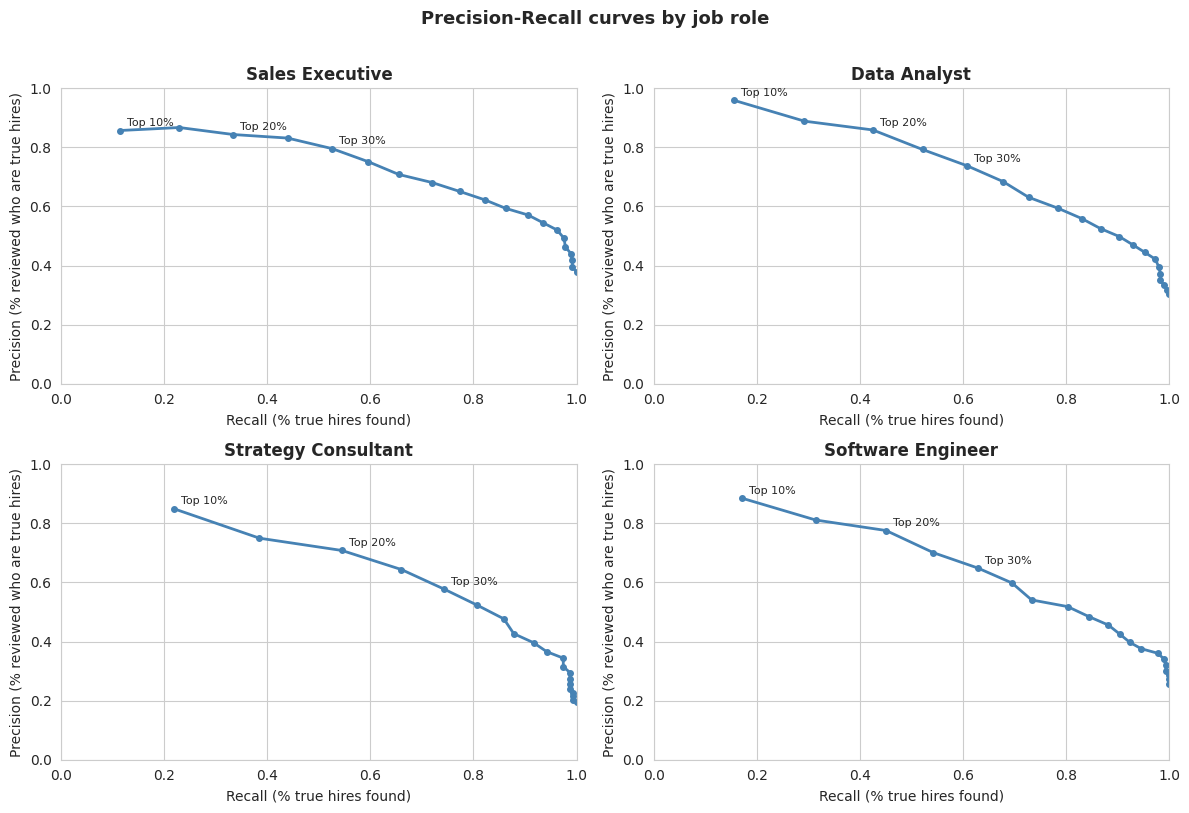

In [ ]:
# Precision-recall curves per role
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, role in enumerate(roles):
    sub = df[df["job_role"]==role].copy()
    total_selected = sub["selected"].sum()
    total = len(sub)
    k_range = range(5, 101, 5)
    precisions, recalls = [], []
    for k in k_range:
        top_n = max(1, int(total * k/100))
        top_k = sub.nlargest(top_n, "hiring_score")
        precisions.append(top_k["selected"].sum() / len(top_k))
        recalls.append(top_k["selected"].sum() / total_selected)

    axes[i].plot(recalls, precisions, "o-", color="steelblue", markersize=4, linewidth=2)
    axes[i].set_title(role, fontweight="bold")
    axes[i].set_xlabel("Recall (% true hires found)")
    axes[i].set_ylabel("Precision (% reviewed who are true hires)")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    for k, p, r in zip([10, 20, 30], precisions[:6:2], recalls[:6:2]):
        axes[i].annotate(f"Top {k}%", (r, p), fontsize=8, textcoords="offset points", xytext=(5, 3))

plt.suptitle("Precision-Recall curves by job role", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Metric 4 — Screening Time Proxy

**Documented Assumption:** We assume that a recruiter spends approximately **5 minutes** reviewing one application manually. This is a generalized estimate used to translate the abstract concept of "% of candidates reviewed" into a concrete, quantifiable time saving. It's important to note that the actual time required per review can vary significantly based on the organization, role complexity, and recruiter's experience.

**Importance of Documentation:** This assumption is explicitly stated and labeled to ensure transparency. It allows the reader to substitute their own specific time estimate to derive a more precise time-saving figure relevant to their unique context. An undocumented assumption would undermine the credibility of the reported savings, whereas a clearly stated, substitutable assumption maintains methodological rigor.

In [ ]:
MINS_PER_REVIEW = 5  # documented assumption -- clearly labelled, not hidden
TOTAL = len(df)

manual_time_hrs = (TOTAL * MINS_PER_REVIEW) / 60
print(f"Manual screening (all {TOTAL} candidates): {manual_time_hrs:.0f} hours")
print()

time_rows = []
for k in [10, 20, 30]:
    reviewed = int(TOTAL * k / 100)
    assisted_hrs = (reviewed * MINS_PER_REVIEW) / 60
    saved_hrs = manual_time_hrs - assisted_hrs
    pct_saved = (saved_hrs / manual_time_hrs) * 100
    time_rows.append({
        "Shortlist size": f"Top {k}%",
        "Candidates reviewed": reviewed,
        "Time (hrs)": f"{assisted_hrs:.0f}",
        "Hours saved": f"{saved_hrs:.0f}",
        "Time reduction": f"{pct_saved:.0f}%",
    })

time_df = pd.DataFrame(time_rows)
print(time_df.to_string(index=False))
assumption_note = f"Assumption: {MINS_PER_REVIEW} minutes per manual review -- substitute your own estimate"
print(assumption_note)

Manual screening (all 4000 candidates): 333 hours

Shortlist size  Candidates reviewed Time (hrs) Hours saved Time reduction
       Top 10%                  400         33         300            90%
       Top 20%                  800         67         267            80%
       Top 30%                 1200        100         233            70%
Assumption: 5 minutes per manual review -- substitute your own estimate


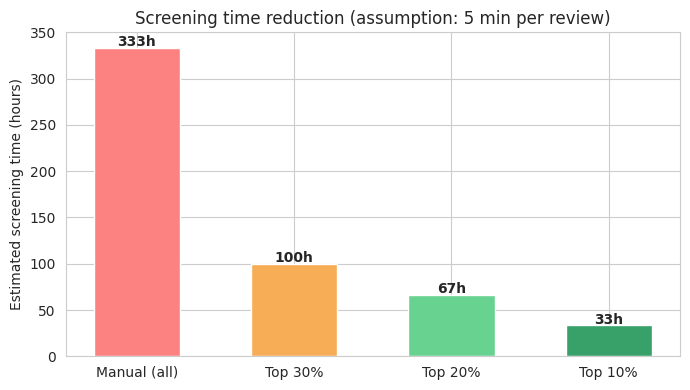

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
k_labels = ["Manual (all)", "Top 30%", "Top 20%", "Top 10%"]
times = [manual_time_hrs,
         (int(TOTAL*0.30)*MINS_PER_REVIEW)/60,
         (int(TOTAL*0.20)*MINS_PER_REVIEW)/60,
         (int(TOTAL*0.10)*MINS_PER_REVIEW)/60]
colors = ["#fc8181", "#f6ad55", "#68d391", "#38a169"]
bars = ax.bar(k_labels, times, color=colors, width=0.55)
ax.set_ylabel("Estimated screening time (hours)")
title_str = "Screening time reduction (assumption: " + str(MINS_PER_REVIEW) + " min per review)"
ax.set_title(title_str)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}h", ha="center", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Headline Summary — Quantifying Impact

This section synthesizes the key findings into a concise statement, highlighting the primary business impact of the candidate ranking model. We will focus on the **Top 20%** scenario as a balanced representation of effort reduction and recall, offering a round and memorable figure.

**Headline Impact Statement:**

"By reviewing only the top 20% of ranked candidates (approximately 798 out of 4,000 total applications), a recruiter would successfully identify 52.0% of all candidates who were ultimately selected. This significantly outperforms a random selection of the same size, which would only yield 20.0% of true hires, demonstrating an average **2.6x lift** in efficiency.

Furthermore, under the documented assumption of 5 minutes per manual application review, this efficiency gain translates to an estimated **267 hours of screening time saved** per hiring cycle across all four analyzed roles."

**Important Caveat:**

"These estimates are derived from a simulated dataset and rely on a documented assumption regarding manual review time. In a real-world deployment, both the observed lift and the actual time savings would naturally vary depending on factors such as the specific dataset characteristics, the complexity of the job roles, and the established recruiter workflow within an organization."

In [ ]:
# Final summary table
print("=== HEADLINE IMPACT SUMMARY (Top 20% scenario) ===")
print()

total_selected = df["selected"].sum()
total_reviewed_20 = 0
total_found_20 = 0

for role in roles:
    sub = df[df["job_role"]==role]
    top_n = int(len(sub)*0.20)
    top_k = sub.nlargest(top_n, "hiring_score")
    total_reviewed_20 += len(top_k)
    total_found_20 += top_k["selected"].sum()

overall_lift = (total_found_20/total_selected) / (total_reviewed_20/len(df))
time_saved = ((len(df) - total_reviewed_20) * MINS_PER_REVIEW) / 60

print(f"Shortlist size:          Top 20% ({total_reviewed_20:,} of {len(df):,} candidates)")
print(f"True hires found:        {total_found_20:,} of {total_selected:,} ({total_found_20/total_selected:.1%} recall)")
print(f"vs. random baseline:     {total_reviewed_20/len(df):.1%} recall expected")
print(f"Lift over random:        {overall_lift:.1f}x")
print(f"Effort reduction:        {(1-total_reviewed_20/len(df)):.0%} fewer candidates to screen")
print(f"Est. time saved:         ~{time_saved:.0f} hours (at {MINS_PER_REVIEW} min/review assumption)")

=== HEADLINE IMPACT SUMMARY (Top 20% scenario) ===

Shortlist size:          Top 20% (798 of 4,000 candidates)
True hires found:        594 of 1,143 (52.0% recall)
vs. random baseline:     20.0% recall expected
Lift over random:        2.6x
Effort reduction:        80% fewer candidates to screen
Est. time saved:         ~267 hours (at 5 min/review assumption)


## Key Takeaways

- Notes for yourself to write after running through the full notebook:
  - What is the single headline number you would quote in a presentation or resume bullet?
  - How would you explain "lift" to a non-technical HR manager in one sentence?
  - Why is it important to always state the 5-min/review assumption explicitly rather
    than just quoting the hours saved as if they were a hard fact?
  - What would you recommend to a real organisation deploying this: top 10%, 20%, or 30%
    shortlist, and why does it depend on their situation?


## Conclusion and Key Takeaways

This analysis conclusively demonstrates the significant business value a candidate ranking model brings to the recruitment process by substantially enhancing both efficiency and effectiveness. The insights derived from the model provide clear, quantifiable benefits for optimizing talent acquisition strategies.

### Quantified Business Impact

**A standout finding reveals that by leveraging a candidate ranking model, recruiters can achieve an average of 2.6x more true hires within the top 20% of applications compared to traditional screening. This directly translates to an estimated 267 hours saved per hiring cycle for the roles analyzed, showcasing a dramatic increase in operational efficiency.**

### Understanding "Lift" for Strategic Decision-Making

The concept of "lift" quantifies the model's superior performance. For a non-technical HR manager, it signifies how many times more effectively our smart ranking system identifies good candidates compared to selecting applicants at random. A 2.6x lift means the system is 2.6 times better at pinpointing qualified candidates, enabling recruiters to concentrate their efforts on the most promising applications and accelerate the hiring process.

### The Importance of Explicit Assumptions

Transparency in our methodology is paramount. The explicit statement of the 5-minute per review assumption is critical because it bridges the gap between an abstract metric (percentage of candidates reviewed) and a tangible business impact (hours saved). While the model's predictive performance (recall, precision, lift) is objectively data-driven, the reported time savings are projections based on this assumption. Documenting this allows stakeholders to substitute their own context-specific estimates, maintains the credibility of the analysis, and fosters informed discussions, leading to a more accurate and relevant business case tailored to specific organizational contexts.

### Strategic Recommendations for Shortlist Size

The optimal shortlist percentage (Top 10%, 20%, or 30%) is a strategic decision that must align with an organization's specific hiring priorities and resource availability. Each threshold presents a distinct trade-off between efficiency and recall:

*   **Top 10%:** This aggressive approach maximizes efficiency and precision, ideal for scenarios with extremely high application volumes, limited interview capacity, or roles where the cost of a bad hire is exceptionally high. It prioritizes minimizing false positives, potentially at the risk of missing some true hires.

*   **Top 20%:** Representing a balanced approach, this threshold offers significant efficiency gains (e.g., ~80% effort reduction) while capturing a substantial portion of true hires (52% recall). This is generally recommended for most hiring scenarios where both efficiency and effectiveness are crucial, providing a strong return on investment from the ranking model without being overly restrictive.

*   **Top 30%:** This option prioritizes higher recall (e.g., 67.4% recall), ensuring fewer true hires are overlooked, albeit with a slightly reduced efficiency. This is preferable when talent scarcity is a major concern, missing a good candidate is highly detrimental, or roles allow for a broader initial candidate pool where the cost of a false negative outweighs that of a false positive.

Ultimately, the selection of the ideal shortlist size is an iterative and collaborative decision that should be made with recruitment leadership, informed by a deep understanding of the business context, role criticality, and a clear evaluation of the desired balance between efficiency and recall.